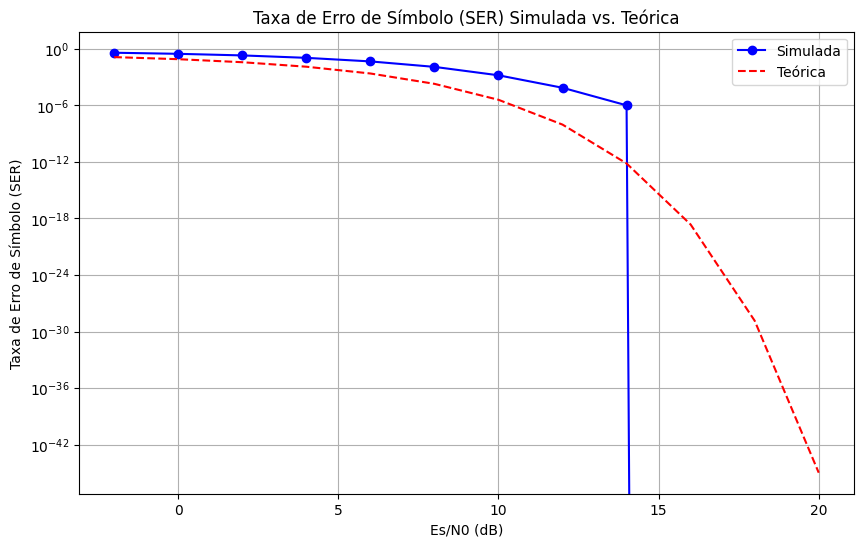

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Função de modulação (já implementada)
def modulator(values):
    raiz2 = np.sqrt(2)
    mapping = {
        0: (1/raiz2) + 1j*(1/raiz2),
        1: (-1/raiz2) + 1j*(1/raiz2),
        2: (1/raiz2) - 1j*(1/raiz2),
        3: (-1/raiz2) - 1j*(1/raiz2)
    }
    symbols = np.array([mapping[v] for v in values])
    return symbols

# Função de demodulação (já implementada)
def demodulator(symbols):
    raiz2 = np.sqrt(2)
    decoded = []
    for s in symbols:
        real = s.real
        imag = s.imag
        if real >= 0 and imag >= 0:
            decoded.append(0)
        elif real < 0 and imag >= 0:
            decoded.append(1)
        elif real >= 0 and imag < 0:
            decoded.append(2)
        else:
            decoded.append(3)
    return np.array(decoded)

# Função para calcular SER teórica
def theoretical_SER(Es_N0_dB):
    Es_N0 = 10**(Es_N0_dB / 10)  # Converter dB para escala linear
    return 0.5 * erfc(np.sqrt(Es_N0))

# Parâmetros
N = 1000000  # Tamanho do vetor
Es_N0_dB_range = np.arange(-2, 21, 2)  # Faixa de Es/N0 em dB

# Gerar valores aleatórios (0 a 3)
original_values = np.random.randint(0, 4, N)

# Modulação
symbols = modulator(original_values)

# Vetor para armazenar o erro de símbolo simulado
SER_simulated = []

# Adição de ruído e cálculo da SER simulada para cada valor de Es/N0
for Es_N0_dB in Es_N0_dB_range:
    noise_std = np.sqrt(1 / (2 * (10**(Es_N0_dB / 10))))  # Desvio padrão do ruído

    # Adicionar ruído gaussiano branco (AWGN)
    noise = noise_std * (np.random.randn(N) + 1j * np.random.randn(N))
    noisy_symbols = symbols + noise

    # Demodulação
    recovered_values = demodulator(noisy_symbols)

    # Cálculo do erro de símbolo (SER)
    error_symbols = np.sum(original_values != recovered_values)
    SER_simulated.append(error_symbols / N)

# Calcular a SER teórica para cada valor de Es/N0
SER_theoretical = theoretical_SER(Es_N0_dB_range)

# Plotar as curvas comparando a SER simulada e teórica
plt.figure(figsize=(10,6))
plt.semilogy(Es_N0_dB_range, SER_simulated, 'b-o', label='Simulada')
plt.semilogy(Es_N0_dB_range, SER_theoretical, 'r--', label='Teórica')
plt.xlabel('Es/N0 (dB)')
plt.ylabel('Taxa de Erro de Símbolo (SER)')
plt.title('Taxa de Erro de Símbolo (SER) Simulada vs. Teórica')
plt.grid(True)
plt.legend()
plt.show()